<a href="https://colab.research.google.com/github/AdrionRosanelli/LoRa_Sionna/blob/main/LoRa_SionnaPHY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Teste Inicial para Implementar LoRa no Sionna PHY.**

Implementação realizada a seguir:

DESCRIÇÕES E CÓDIGOS...

Código abaixo implementado utilizando o Claude. (EM REVISÃO...)

# Implementação da camada física do LoRa no Sionna

*   Implementa geração de chirps
*   Modulação/Demodulação utilizando os chirps
*   Gera pacotes do LoRa
*   Simula canal utililizando Rayleigh
*   Visualiza chirps e BER


OBS: Realiza aproximação da QPSK para o Mapper/Demapper. Modelagem do canal aproximada com Rayleigh e OFDM...

### Imports

Instalação e importação das bibliotecas. (Import do tutorial Part 1 Sionna PHY)

In [9]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For plotting
%matplotlib inline
# also try %matplotlib widget

import matplotlib.pyplot as plt

# for performance measurements
import time

In [10]:
# Imports à serem verificados (se é necessário)

# import tensorflow as tf
# import numpy as np
# import matplotlib.pyplot as plt
# from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, compute_paths
# from sionna.channel import OFDMChannel, RayleighBlockFading
from sionna.phy.channel import OFDMChannel, RayleighBlockFading
# from sionna.mimo import StreamManagement
from sionna.phy.mimo import StreamManagement
# from sionna.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer
# from sionna.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
# from sionna.mapping import Mapper, Demapper
from sionna.phy.mapping import Mapper, Demapper, Constellation, BinarySource
# from sionna.utils import BinarySource, ebnodb2no, sim_ber
from sionna.phy.utils import ebnodb2no, sim_ber
import sionna

from scipy.signal import hilbert

### Implementação da camada física do LoRa no bloco.

1. Inicialização

  *   Define parâmetros do LoRa.
  *   Configura OFDM para simular modulação LoRa.

2. Definição dos compontentes:

  *   Grade de recursos (???? dúvida do que é).
  *   Codificação.
  *   Modulação (QPSK como aproximação do LoRa).
  *   Definição do canal (Rayleigh e OFDM).

3. Geração de chirps do LoRa:

  *   Chirp linear variando de 0 a BW.

4. Modulação e Demodulação usando chirp.

5. Geração de pacotes:

  *   Preâmbulo.
  *   Sincronismo.
  *   Cabeçalho.
  *   Payload.

6. Codificação dos bits

7. Simula transmissão

8. Plot da BER

9. Analise do chirp

In [11]:
class LoRaPhysicalLayer:
    """
    Implementação da camada física do LoRa usando Sionna
    """

    def __init__(self,
                 spreading_factor=7,      # SF7 = 128 chips por símbolo
                 bandwidth=125e3,         # 125 kHz
                 coding_rate=1,           # Taxa de codificação
                 num_preamble=8,          # Símbolos de preâmbulo
                 sync_word=0x34,          # Palavra de sincronização
                 crc_on=True):            # Habilitar CRC

        self.sf = spreading_factor
        self.bw = bandwidth
        self.cr = coding_rate
        self.num_preamble = num_preamble
        self.sync_word = sync_word
        self.crc_on = crc_on

        # Parâmetros derivados
        self.n_chips = 2**self.sf  # Número de chips por símbolo
        self.symbol_duration = self.n_chips / self.bw
        self.chip_duration = 1 / self.bw

        # Configuração OFDM para simular LoRa
        self.num_ofdm_symbols = 14
        self.fft_size = 128
        self.num_tx = 1
        self.num_rx = 1
        self.num_streams_per_tx = 1

        self._setup_sionna_components()


    def _setup_sionna_components(self):
        """Configura os componentes do Sionna"""

        # Stream management
        self.sm = StreamManagement(np.array([[1]]), self.num_streams_per_tx)

        # Resource grid
        self.rg = ResourceGrid(
            num_ofdm_symbols=self.num_ofdm_symbols,
            fft_size=self.fft_size,
            subcarrier_spacing=15e3,
            num_tx=self.num_tx,
            num_streams_per_tx=self.num_streams_per_tx,
            cyclic_prefix_length=6,
            pilot_pattern="kronecker",
            pilot_ofdm_symbol_indices=[2, 11]
        )

        # Codificação e modulação
        self.encoder = LDPC5GEncoder(k=100, n=128)  # Taxa de código ~0.78
        self.decoder = LDPC5GDecoder(self.encoder)

        # Modulação QPSK (similar ao LoRa)
        self.constellation = Constellation("qam", 2) #num_bits_symbol = 2 para QPSK
        self.mapper = Mapper(constellation=self.constellation)
        self.demapper = Demapper("app", constellation=self.constellation)

        #self.mapper = Mapper("qpsk")
        #self.demapper = Demapper("qpsk", "app")

        # Mapeamento para grade de recursos
        self.rg_mapper = ResourceGridMapper(self.rg)

        # Canal
        self.num_rx_ant = 1
        self.num_tx_ant = 1

        self.channel_model = RayleighBlockFading(
            num_rx=self.num_rx, num_rx_ant=self.num_rx_ant,
            num_tx=self.num_tx, num_tx_ant=self.num_tx_ant
        )

        # Canal OFDM
        self.channel = OFDMChannel(
            channel_model=self.channel_model,
            resource_grid=self.rg,
            add_awgn=True,
            normalize_channel=True,
            return_channel=True
        )

        # Estimação de canal e equalização
        self.ls_est = LSChannelEstimator(self.rg, interpolation_type="nn")
        self.lmmse_equ = LMMSEEqualizer(self.rg, self.sm, constellation_type="qpsk")


    def generate_chirp_sequence(self, initial_frequency=0):
        """
        Gera sequência chirp característica do LoRa
        """
        t = np.linspace(0, self.symbol_duration, self.n_chips, endpoint=False)

        # Chirp linear com frequência variando de 0 a BW
        freq_slope = self.bw / self.symbol_duration
        chirp = np.exp(1j * 2 * np.pi * (
            initial_frequency * t + 0.5 * freq_slope * t**2
        ))

        return chirp, t


    def modulate_symbol(self, symbol_value):
        """
        Modula um símbolo usando modulação chirp do LoRa
        """
        # Frequência inicial baseada no valor do símbolo
        freq_offset = (symbol_value * self.bw) / self.n_chips
        chirp, t = self.generate_chirp_sequence(freq_offset)

        return chirp, t

    def calculate_instantaneous_frequency(self, chirp):
        """
        Calcula a frequência instantânea do chirp usando transformada de Hilbert
        """
        # Aplicar transformada de Hilbert para obter sinal analítico
        analytic_signal = hilbert(np.real(chirp))

        # Calcular fase instantânea
        phase = np.unwrap(np.angle(analytic_signal))

        # Frequência instantânea = derivada da fase / (2*pi)
        dt = self.chip_duration
        freq_inst = np.diff(phase) / (2 * np.pi * dt)

        return freq_inst


    def demodulate_symbol(self, received_chirp):
        """
        Demodula um símbolo LoRa usando FFT
        """
        # Chirp de referência conjugado
        ref_chirp = np.conj(self.generate_chirp_sequence())

        # Multiplicação com chirp de referência
        dechirped = received_chirp * ref_chirp

        # FFT para encontrar o pico de frequência
        fft_result = np.fft.fft(dechirped)
        symbol_value = np.argmax(np.abs(fft_result))

        return symbol_value

    def generate_lora_packet(self, payload_bits):
        """
        Gera um pacote LoRa completo
        """
        packet_symbols = []

        # 1. Preâmbulo (chirps up)
        for _ in range(self.num_preamble):
            chirp = self.generate_chirp_sequence()
            packet_symbols.append(chirp)

        # 2. Palavra de sincronização
        sync_symbols = self.encode_data([self.sync_word])
        for symbol in sync_symbols:
            packet_symbols.append(symbol)

        # 3. Cabeçalho (simplificado)
        header = [len(payload_bits) // 8, self.cr, self.crc_on]
        header_symbols = self.encode_data(header)
        for symbol in header_symbols:
            packet_symbols.append(symbol)

        # 4. Payload
        payload_symbols = self.encode_data(payload_bits)
        for symbol in payload_symbols:
            packet_symbols.append(symbol)

        return np.concatenate(packet_symbols)

    def encode_data(self, data_bits):
        """
        Codifica dados em símbolos LoRa
        """
        symbols = []

        # Agrupa bits em símbolos de SF bits cada
        for i in range(0, len(data_bits), self.sf):
            symbol_bits = data_bits[i:i+self.sf]
            if len(symbol_bits) < self.sf:
                # Padding com zeros
                symbol_bits.extend([0] * (self.sf - len(symbol_bits)))

            # Converte bits para valor do símbolo
            symbol_value = sum(bit * (2**idx) for idx, bit in enumerate(symbol_bits))

            # Modula símbolo
            chirp_symbol = self.modulate_symbol(symbol_value)
            symbols.append(chirp_symbol)

        return symbols

    def simulate_transmission(self, payload_bits, ebno_db_range):
        """
        Simula transmissão LoRa usando Sionna
        """
        # Fonte de bits
        binary_source = BinarySource()

        # Gera pacote LoRa
        lora_packet = self.generate_lora_packet(payload_bits)

        # Converte para formato compatível com Sionna
        batch_size = 64
        num_bits_per_symbol = 2  # QPSK

        # Simulação BER
        ber_results = []
        ber_theory = []

        for ebno_db in ebno_db_range:
            # Gera bits aleatórios
            bits = binary_source([batch_size, self.encoder.k])

            # Codificação
            codewords = self.encoder(bits)

            # Modulação
            symbols = self.mapper(codewords)

            # Mapeamento para grade de recursos
            symbols_rg = self.rg_mapper(symbols)

            # Canal
            no = ebnodb2no(ebno_db, num_bits_per_symbol, self.encoder.coderate)
            y, h = self.channel([symbols_rg, no])

            # Estimação de canal
            h_est, _ = self.ls_est([y, no])

            # Equalização
            symbols_eq, _ = self.lmmse_equ([y, h_est, no])

            # Demodulação
            llr = self.demapper([symbols_eq, no])

            # Decodificação
            bits_decoded = self.decoder(llr)

            # Calcula BER
            ber = tf.reduce_mean(tf.cast(tf.not_equal(bits, bits_decoded), tf.float32))
            ber_results.append(ber.numpy())

            # BER teórica para QPSK em canal Rayleigh
            ber_theory.append(0.5 * (1 - np.sqrt(10**(ebno_db/10) / (2 + 10**(ebno_db/10)))))

        return ber_results, ber_theory

    def plot_ber_performance(self, ebno_db_range, ber_sim, ber_theory):
        """
        Plota curvas de BER
        """
        plt.figure(figsize=(10, 6))
        plt.semilogy(ebno_db_range, ber_sim, 'bo-', label='LoRa Simulado')
        plt.semilogy(ebno_db_range, ber_theory, 'r--', label='QPSK Teórico (Rayleigh)')
        plt.xlabel('Eb/N0 (dB)')
        plt.ylabel('Bit Error Rate')
        plt.title(f'Desempenho BER - LoRa SF{self.sf}')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.xlim([ebno_db_range[0], ebno_db_range[-1]])
        plt.ylim([1e-4, 1])
        plt.show()

    def analyze_chirp_spectrum(self):
        """
        Analisa o espectro dos chirps LoRa
        """
        # Gera diferentes chirps
        chirps = []
        for symbol_val in [0, self.n_chips//4, self.n_chips//2, 3*self.n_chips//4]:
            chirp, t = self.modulate_symbol(symbol_val)
            chirps.append(chirp)

        # Calcula espectros
        freqs = np.fft.fftfreq(self.n_chips, self.chip_duration)

        plt.figure(figsize=(12, 8))

        for i, chirp in enumerate(chirps):
            spectrum = np.fft.fft(chirp)
            plt.subplot(2, 2, i+1)
            plt.plot(freqs/1000, 20*np.log10(np.abs(spectrum)))
            plt.title(f'Espectro - Símbolo {i*(self.n_chips//4)}')
            plt.xlabel('Frequência (kHz)')
            plt.ylabel('Magnitude (dB)')
            plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

print("Classe LoRaPhysicalLayer implementada com suceso.")

Classe LoRaPhysicalLayer implementada com suceso.


### Testes e Simulação do modelo

Inicialização e configuração da LoRa PHY:

In [12]:
print("=== Simulação da Camada Física LoRa com Sionna ===\n")

# Inicializa LoRa PHY
lora_phy = LoRaPhysicalLayer(
        spreading_factor=7,
        bandwidth=125e3,
        coding_rate=1
)
print(f"Configurações LoRa:")
print(f"- Spreading Factor: {lora_phy.sf}")
print(f"- Largura de Banda: {lora_phy.bw/1000:.0f} kHz")
print(f"- Chips por símbolo: {lora_phy.n_chips}")
print(f"- Duração do símbolo: {lora_phy.symbol_duration*1000:.2f} ms")
print(f"- Taxa de símbolo: {1/lora_phy.symbol_duration:.2f} símbolos/s\n")

=== Simulação da Camada Física LoRa com Sionna ===

Configurações LoRa:
- Spreading Factor: 7
- Largura de Banda: 125 kHz
- Chips por símbolo: 128
- Duração do símbolo: 1.02 ms
- Taxa de símbolo: 976.56 símbolos/s



Geração de dados e pacotes:

In [13]:
# Dados para transmissão
payload = [1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1] * 4  # 64 bits
print(f"Payload: {len(payload)} bits")

# Gera pacote LoRa
packet = lora_phy.generate_lora_packet(payload)
print(f"Pacote gerado: {len(packet)} amostras\n")
print(f"Duração total do pacote: {len(packet) * lora_phy.chip_duration * 1000:.2f} ms")

Payload: 64 bits
Pacote gerado: 40 amostras

Duração total do pacote: 0.32 ms


Análise espectral dos chirps: (OBS: Verificar veracidade dos resultados)

Analisando espectro dos chirps...


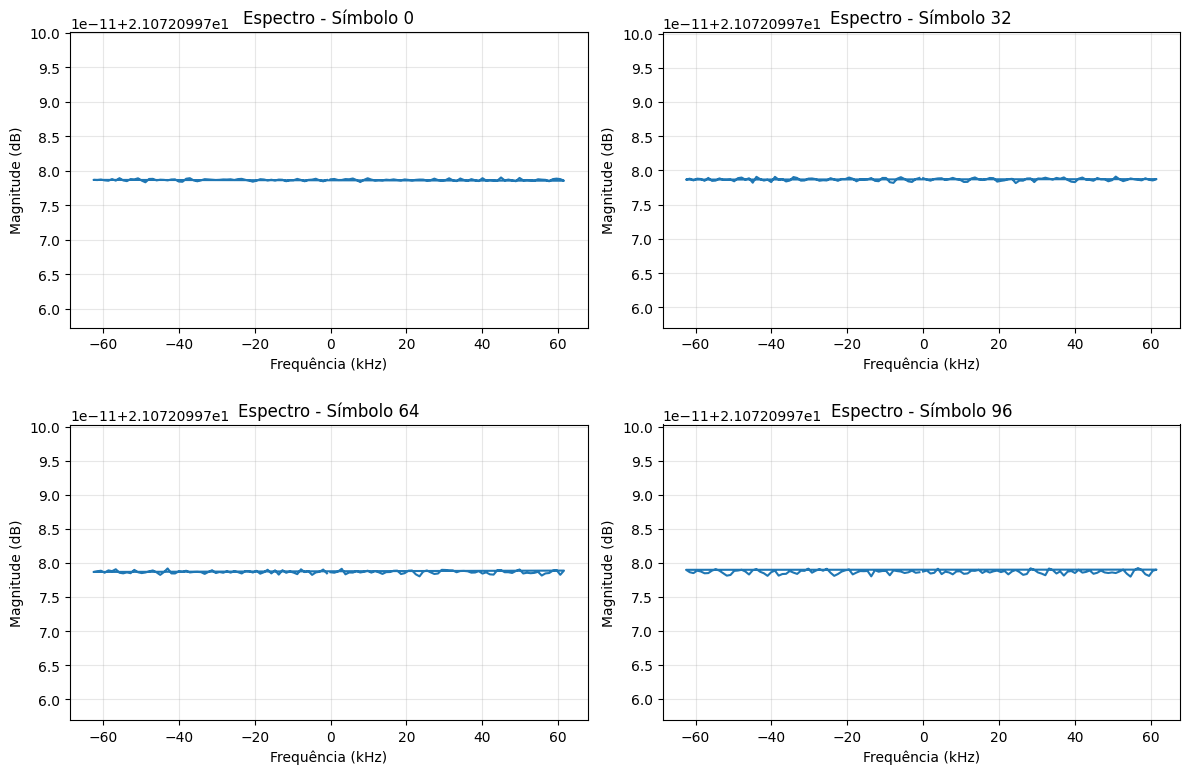

In [14]:
# Análise espectral
print("Analisando espectro dos chirps...")
lora_phy.analyze_chirp_spectrum()

Analise dos chirps no tempo:

Visualiza alguns chirps no domínio do tempo


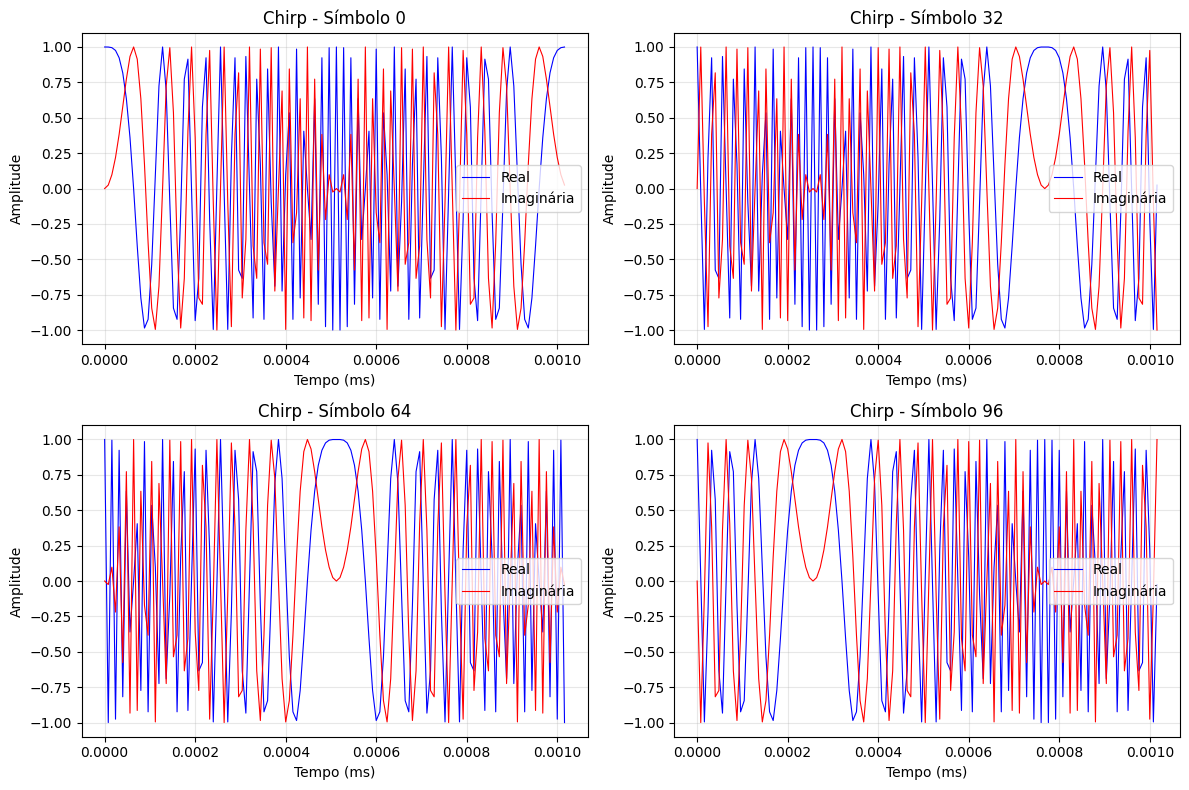

In [15]:
print("Visualiza alguns chirps no domínio do tempo")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

symbol_values = [0, 32, 64, 96]
t = np.linspace(0, lora_phy.symbol_duration*1000, lora_phy.n_chips, endpoint=False)

for i, symbol_val in enumerate(symbol_values):
    chirp, t = lora_phy.modulate_symbol(symbol_val)

    # Plota parte real
    axes[i].plot(t, np.real(chirp), 'b-', linewidth=0.8, label='Real')
    axes[i].plot(t, np.imag(chirp), 'r-', linewidth=0.8, label='Imaginária')
    axes[i].set_title(f'Chirp - Símbolo {symbol_val}')
    axes[i].set_xlabel('Tempo (ms)')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

Análise da frequência pelo tempo:

<ipython-input-16-741935269>:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


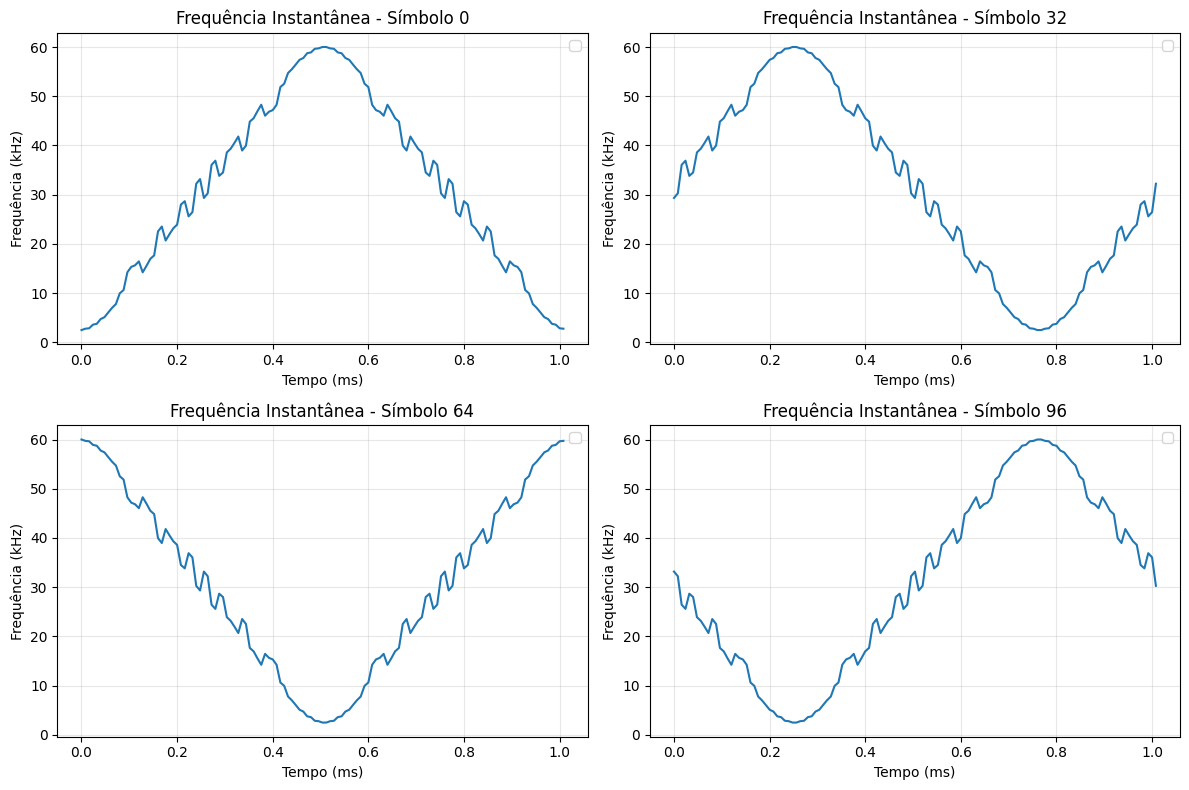

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

symbol_values = [0, 32, 64, 96]

for i, symbol_val in enumerate(symbol_values):
    chirp, t = lora_phy.modulate_symbol(symbol_val)
    freq_inst = lora_phy.calculate_instantaneous_frequency(chirp)
    t_freq = t[:-1]  # Tempo para frequência instantânea (um ponto a menos)

    # Plota parte real
    axes[i].plot(t_freq*1000, freq_inst/1000)
    axes[i].set_title(f'Frequência Instantânea - Símbolo {symbol_val}')
    axes[i].set_xlabel('Tempo (ms)')
    axes[i].set_ylabel('Frequência (kHz)')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

Teste da modulação/demodulação:

In [18]:
# Teste de modulação/demodulação
print("\nTeste de modulação/demodulação:")
test_symbols = [0, 32, 64, 96, 127]

for symbol_val in test_symbols:
        # Modula
        modulated, t = lora_phy.modulate_symbol(symbol_val)

        # Adiciona ruído
        noise_power = 0.1
        noisy_signal = modulated + np.sqrt(noise_power/2) * (
            np.random.randn(len(modulated)) + 1j*np.random.randn(len(modulated))
        )

# Demodula
demod_symbol = lora_phy.demodulate_symbol(noisy_signal)

print(f"Original: {symbol_val:3d} -> Demodulado: {demod_symbol:3d} "
      f"(Erro: {abs(symbol_val - demod_symbol):3d})")


Teste de modulação/demodulação:
Original: 127 -> Demodulado: 127 (Erro:   0)


Teste Modulação/Demodulação com variação do ruído:

In [19]:
# Teste de modulação e demodulação com ruído
print("Testando com diferentes níveis de ruído...")

test_symbols = [0, 32, 64, 96, 127]
noise_levels = [0.01, 0.1, 0.5, 1.0, 20.0]  # Diferentes níveis de ruído

for noise_power in noise_levels:
    print(f"Nível de ruído: {noise_power}")
    errors = 0

    for symbol_val in test_symbols:
        # Modula
        modulated, t = lora_phy.modulate_symbol(symbol_val)

        # Adiciona ruído AWGN complexo
        noise = np.sqrt(noise_power/2) * (
            np.random.randn(len(modulated)) + 1j*np.random.randn(len(modulated))
        )
        noisy_signal = modulated + noise

        # Demodula
        demod_symbol = lora_phy.demodulate_symbol(noisy_signal)

        error = abs(symbol_val - demod_symbol)
        if error > 0:
            errors += 1

        print(f"  Original: {symbol_val:3d} -> Demodulado: {demod_symbol:3d} (Erro: {error:3d})")

    print(f"  Taxa de erro: {errors}/{len(test_symbols)} ({100*errors/len(test_symbols):.1f}%)")

Testando com diferentes níveis de ruído...
Nível de ruído: 0.01
  Original:   0 -> Demodulado:   0 (Erro:   0)
  Original:  32 -> Demodulado:  32 (Erro:   0)
  Original:  64 -> Demodulado:  64 (Erro:   0)
  Original:  96 -> Demodulado:  96 (Erro:   0)
  Original: 127 -> Demodulado: 127 (Erro:   0)
  Taxa de erro: 0/5 (0.0%)
Nível de ruído: 0.1
  Original:   0 -> Demodulado:   0 (Erro:   0)
  Original:  32 -> Demodulado:  32 (Erro:   0)
  Original:  64 -> Demodulado:  64 (Erro:   0)
  Original:  96 -> Demodulado:  96 (Erro:   0)
  Original: 127 -> Demodulado: 127 (Erro:   0)
  Taxa de erro: 0/5 (0.0%)
Nível de ruído: 0.5
  Original:   0 -> Demodulado:   0 (Erro:   0)
  Original:  32 -> Demodulado:  32 (Erro:   0)
  Original:  64 -> Demodulado:  64 (Erro:   0)
  Original:  96 -> Demodulado:  96 (Erro:   0)
  Original: 127 -> Demodulado: 127 (Erro:   0)
  Taxa de erro: 0/5 (0.0%)
Nível de ruído: 1.0
  Original:   0 -> Demodulado:   0 (Erro:   0)
  Original:  32 -> Demodulado:  32 (Erro:  

Análise de desempenho da BER:

In [20]:
# Simulação de desempenho BER
print("Simulando desempenho BER...")
ebno_range = np.arange(-5, 15, 2.5)
ber_sim, ber_theory = lora_phy.simulate_transmission(payload, ebno_range)

# Plota resultados
lora_phy.plot_ber_performance(ebno_range, ber_sim, ber_theory)

Simulando desempenho BER...


InvalidArgumentError: `num_dims` must <= rank(`tensor`)
Condition x <= y did not hold.
First 1 elements of x:
[3]
First 1 elements of y:
[2]